---
# **Week 4: Comprehensive Data Analysis Reporting and Presentation in R**
---
**Project:** Palmer Archipelago Penguins (`palmerpenguins`): from raw data to a predictive model

This notebook is the capstone of the four-week project. It brings the earlier work together in one reproducible pipeline and adds the results, discussion and conclusions needed for the final report.

| Section | Builds on | Purpose |
|---|---|---|
| 1. Setup | Weeks 1-3 | Load packages, fix the random seed, define a consistent colour palette |
| 2. Data Preparation & Cleaning | Week 1 | Audit the raw data, handle missing values, screen for outliers |
| 3. Exploratory Visualization | Week 2 | Charts that reveal patterns, paradoxes and anomalies |
| 4. Statistical Inference | Week 3 | Hypothesis tests, effect sizes, assumption checks |
| 5. Predictive Modeling | Week 3 | Baseline, regression model, cross-validation, model comparison, diagnostics |
| 6. Results Consolidation | Week 4 | One table of findings that answers the original questions |
| 7. Discussion | Week 4 | Interpretation, implications and limitations |
| 8. Conclusion | Week 4 | Lessons learned, challenges overcome, future directions |

---
## **1. Setup: Libraries, Seed and Plot Settings**

In [1]:
pkgs <- c("palmerpenguins", "ggplot2", "dplyr")
for (p in pkgs) if (!requireNamespace(p, quietly = TRUE)) install.packages(p)
invisible(lapply(pkgs, function(p) suppressPackageStartupMessages(library(p, character.only = TRUE))))

options(repr.plot.width = 8, repr.plot.height = 5.5, width = 110)
set.seed(42)

# One palette used for every chart so the story stays visually consistent
species_cols <- c(Adelie = "#F8766D", Chinstrap = "#00BA38", Gentoo = "#619CFF")
sex_cols     <- c(female = "#F8766D", male = "#00BFC4")

cat("Packages loaded.\n", R.version.string, "\n")

Packages loaded.
 R version 4.3.3 (2024-02-29) 


---
## **2. Data Preparation & Cleaning** *(Week 1)*

Good analysis starts with knowing what is wrong with the data. This section audits the raw table, documents every cleaning decision and checks that the remaining values are plausible.

**2.1 Structure and missing-value audit**

In [2]:
cat("Raw dimensions:", nrow(penguins), "rows x", ncol(penguins), "columns\n\n")
str(penguins)

Raw dimensions: 344 rows x 8 columns



tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


In [3]:
missing_audit <- data.frame(
  variable    = names(penguins),
  n_missing   = sapply(penguins, function(x) sum(is.na(x))),
  pct_missing = round(100 * sapply(penguins, function(x) mean(is.na(x))), 2),
  row.names   = NULL
)
print(missing_audit)

cat("\nRows with at least one missing value:", sum(!complete.cases(penguins)), "\n")
cat("Duplicate rows:", sum(duplicated(penguins)), "\n")

           variable n_missing pct_missing
1           species         0        0.00
2            island         0        0.00
3    bill_length_mm         2        0.58
4     bill_depth_mm         2        0.58
5 flipper_length_mm         2        0.58
6       body_mass_g         2        0.58
7               sex        11        3.20
8              year         0        0.00



Rows with at least one missing value: 11 


Duplicate rows: 0 


**2.2 Cleaning decisions**

Missing values are rare (11 records have a missing `sex`, 2 have missing measurements), so complete-case deletion is the simplest defensible option: it avoids inventing values and costs only a small share of the data. Every step is logged below.

In [4]:
model_vars <- c("species", "island", "bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g", "sex", "year")

data_clean <- na.omit(penguins[, model_vars])
n_after_na <- nrow(data_clean)

data_clean <- data_clean[data_clean$sex %in% c("female", "male"), ]
data_clean$species <- droplevels(as.factor(data_clean$species))
data_clean$island  <- droplevels(as.factor(data_clean$island))
data_clean$sex     <- droplevels(as.factor(data_clean$sex))
data_clean <- as.data.frame(data_clean)

cleaning_log <- data.frame(
  Step    = c("Raw records",
              "Removed: missing measurement or sex values",
              "Removed: invalid sex labels",
              "Final analysis records"),
  Records = c(nrow(penguins),
              nrow(penguins) - n_after_na,
              n_after_na - nrow(data_clean),
              nrow(data_clean))
)
print(cleaning_log, row.names = FALSE)

                                       Step Records
                                Raw records     344
 Removed: missing measurement or sex values      11
                Removed: invalid sex labels       0
                     Final analysis records     333


**2.3 Outlier screen and descriptive summary**

The 1.5 x IQR rule flags values that sit unusually far from the middle of each distribution. Flagged values are inspected, not automatically deleted, because a large penguin is a real penguin.

In [5]:
num_vars <- c("bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g")

outlier_tbl <- do.call(rbind, lapply(num_vars, function(v) {
  x   <- data_clean[[v]]
  q   <- quantile(x, c(0.25, 0.75))
  iqr <- diff(q)
  lo  <- q[1] - 1.5 * iqr
  hi  <- q[2] + 1.5 * iqr
  data.frame(variable = v, min = min(x), max = max(x),
             lower_fence = round(lo, 1), upper_fence = round(hi, 1),
             n_outliers = sum(x < lo | x > hi))
}))
print(outlier_tbl, row.names = FALSE)

          variable    min    max lower_fence upper_fence n_outliers
    bill_length_mm   32.1   59.6        25.8        62.2          0
     bill_depth_mm   13.1   21.5        10.9        23.3          0
 flipper_length_mm  172.0  231.0       155.5       247.5          0
       body_mass_g 2700.0 6300.0      1712.5      6612.5          0


In [6]:
desc_tbl <- data_clean %>%
  group_by(species) %>%
  summarise(n = n(),
            mean_mass    = round(mean(body_mass_g), 1),
            sd_mass      = round(sd(body_mass_g), 1),
            mean_flipper = round(mean(flipper_length_mm), 1),
            mean_bill_len   = round(mean(bill_length_mm), 1),
            mean_bill_depth = round(mean(bill_depth_mm), 1),
            .groups = "drop")
print(as.data.frame(desc_tbl))

    species   n mean_mass sd_mass mean_flipper mean_bill_len mean_bill_depth
1    Adelie 146    3706.2   458.6        190.1          38.8            18.3
2 Chinstrap  68    3733.1   384.3        195.8          48.8            18.4
3    Gentoo 119    5092.4   501.5        217.2          47.6            15.0


---
## **3. Exploratory Visualization** *(Week 2)*

Each chart is chosen to answer one specific question. Together they motivate the hypotheses tested in Section 4 and the predictors used in Section 5.

**Chart 1: Do bill length and bill depth move together? (scatter plot with trendlines)**

Pooled correlation: r = -0.229


Within-species correlations:


   Adelie Chinstrap    Gentoo 
    0.386     0.654     0.654 


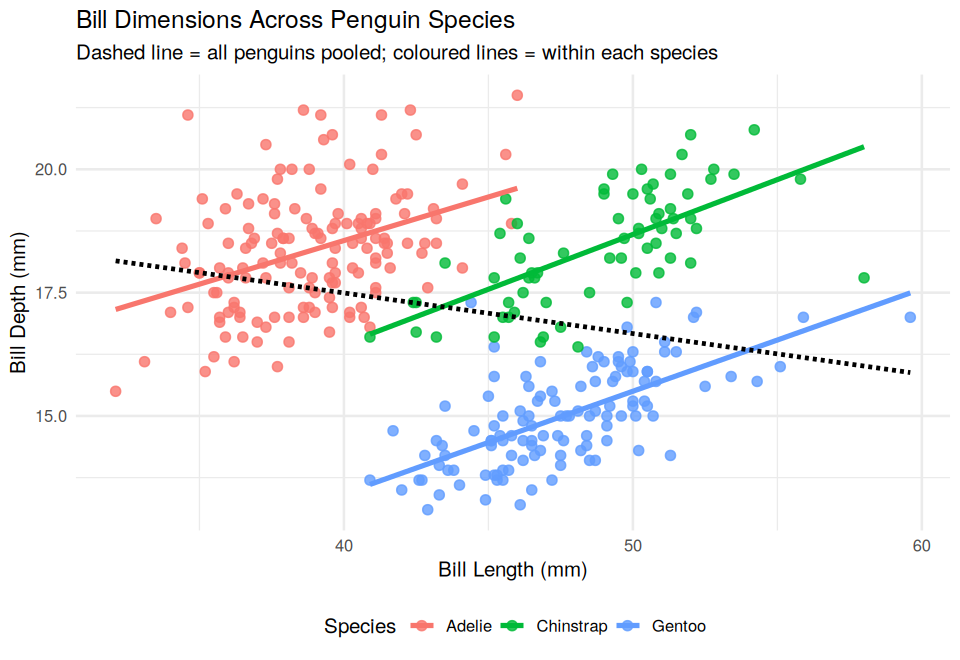

In [7]:
overall_r <- cor(data_clean$bill_length_mm, data_clean$bill_depth_mm)

p1 <- ggplot(data_clean, aes(x = bill_length_mm, y = bill_depth_mm, color = species)) +
  geom_point(alpha = 0.8, size = 2.2) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, linewidth = 1.1) +
  geom_smooth(aes(group = 1), method = "lm", formula = y ~ x, se = FALSE,
              color = "black", linetype = "dashed", linewidth = 1) +
  scale_color_manual(values = species_cols) +
  labs(title = "Bill Dimensions Across Penguin Species",
       subtitle = "Dashed line = all penguins pooled; coloured lines = within each species",
       x = "Bill Length (mm)", y = "Bill Depth (mm)", color = "Species") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")
print(p1)

within_r <- sapply(split(data_clean, data_clean$species),
                   function(d) cor(d$bill_length_mm, d$bill_depth_mm))
cat(sprintf("Pooled correlation: r = %.3f\n", overall_r))
cat("Within-species correlations:\n"); print(round(within_r, 3))

**Chart 2: How is body mass distributed? (histogram with density curves)**

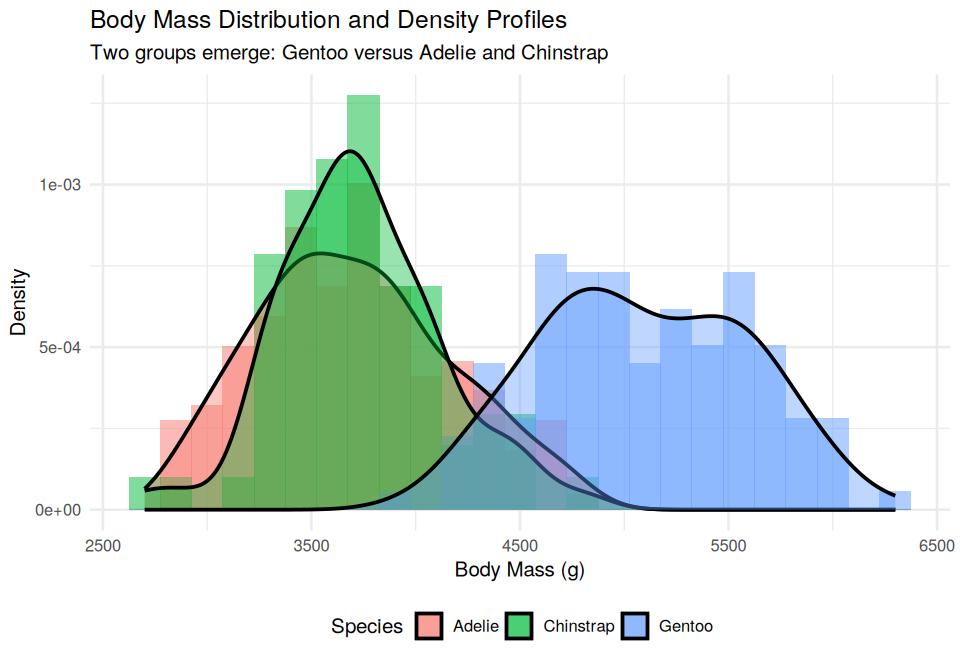

In [8]:
p2 <- ggplot(data_clean, aes(x = body_mass_g, fill = species)) +
  geom_histogram(aes(y = after_stat(density)), bins = 25, alpha = 0.5, position = "identity") +
  geom_density(alpha = 0.4, linewidth = 0.8) +
  scale_fill_manual(values = species_cols) +
  labs(title = "Body Mass Distribution and Density Profiles",
       subtitle = "Two groups emerge: Gentoo versus Adelie and Chinstrap",
       x = "Body Mass (g)", y = "Density", fill = "Species") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")
print(p2)

**Chart 3: Where do the species live, and is the sample balanced by sex? (faceted bar chart)**

           Island
Species     Biscoe Dream Torgersen
  Adelie        44    55        47
  Chinstrap      0    68         0
  Gentoo       119     0         0


Sex
female   male 
   165    168 


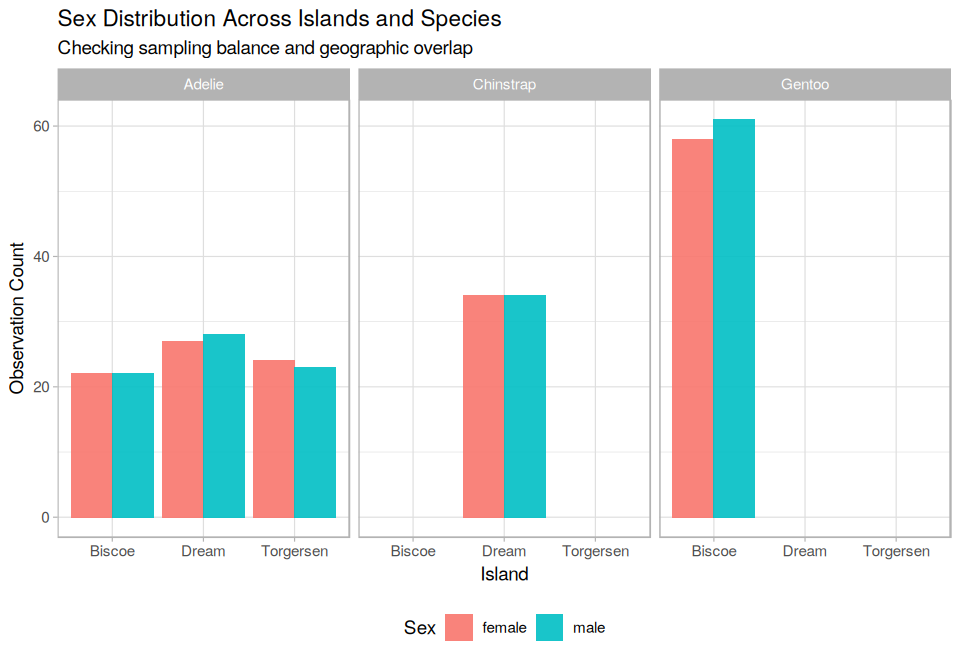

In [9]:
p3 <- ggplot(data_clean, aes(x = island, fill = sex)) +
  geom_bar(position = "dodge", alpha = 0.9) +
  facet_wrap(~ species) +
  scale_fill_manual(values = sex_cols) +
  labs(title = "Sex Distribution Across Islands and Species",
       subtitle = "Checking sampling balance and geographic overlap",
       x = "Island", y = "Observation Count", fill = "Sex") +
  theme_light(base_size = 11) + theme(legend.position = "bottom")
print(p3)

print(table(Species = data_clean$species, Island = data_clean$island))
print(table(Sex = data_clean$sex))

**Chart 4: Are measurements stable over the survey years? (line chart with standard errors)**

  year   species mean_flipper se_flipper
1 2007    Adelie       186.70       0.99
2 2007 Chinstrap       192.42       1.19
3 2007    Gentoo       215.09       0.97
4 2008    Adelie       191.04       0.81
5 2008 Chinstrap       197.72       1.72
6 2008    Gentoo       217.64       0.98
7 2009    Adelie       192.08       0.86
8 2009 Chinstrap       198.08       1.41
9 2009    Gentoo       218.51       1.10


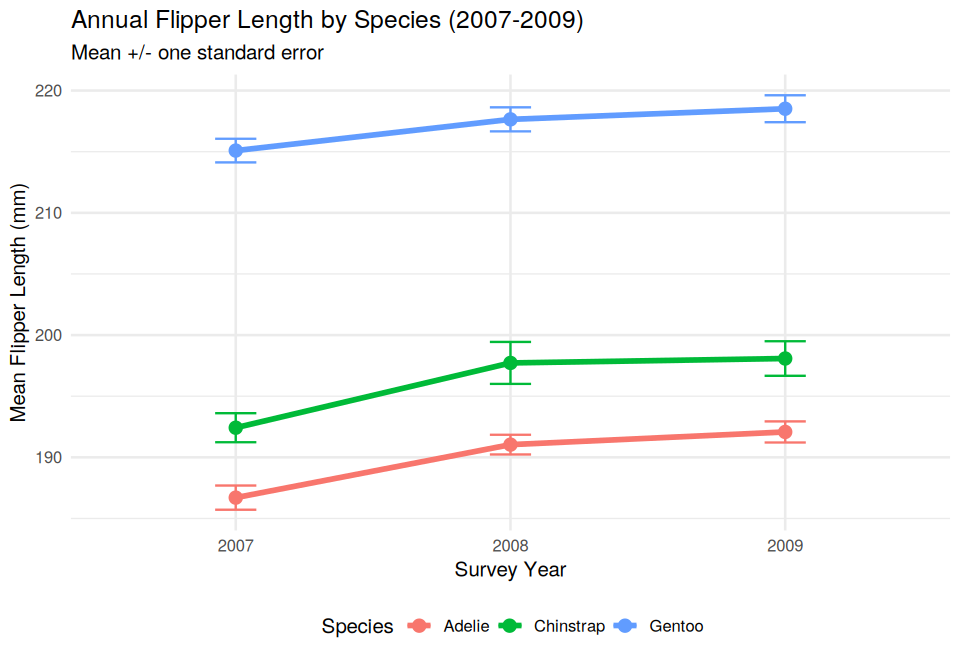

In [10]:
yearly_trend <- data_clean %>%
  group_by(year, species) %>%
  summarise(mean_flipper = mean(flipper_length_mm),
            se_flipper   = sd(flipper_length_mm) / sqrt(n()),
            .groups = "drop")

p4 <- ggplot(yearly_trend, aes(x = factor(year), y = mean_flipper, group = species, color = species)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_flipper - se_flipper, ymax = mean_flipper + se_flipper), width = 0.15) +
  scale_color_manual(values = species_cols) +
  labs(title = "Annual Flipper Length by Species (2007-2009)",
       subtitle = "Mean +/- one standard error",
       x = "Survey Year", y = "Mean Flipper Length (mm)", color = "Species") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")
print(p4)
print(as.data.frame(yearly_trend %>% mutate(across(where(is.numeric) & !year, ~ round(.x, 2)))))

**Chart 5 (new): Which measurements are most related? (correlation heatmap)**

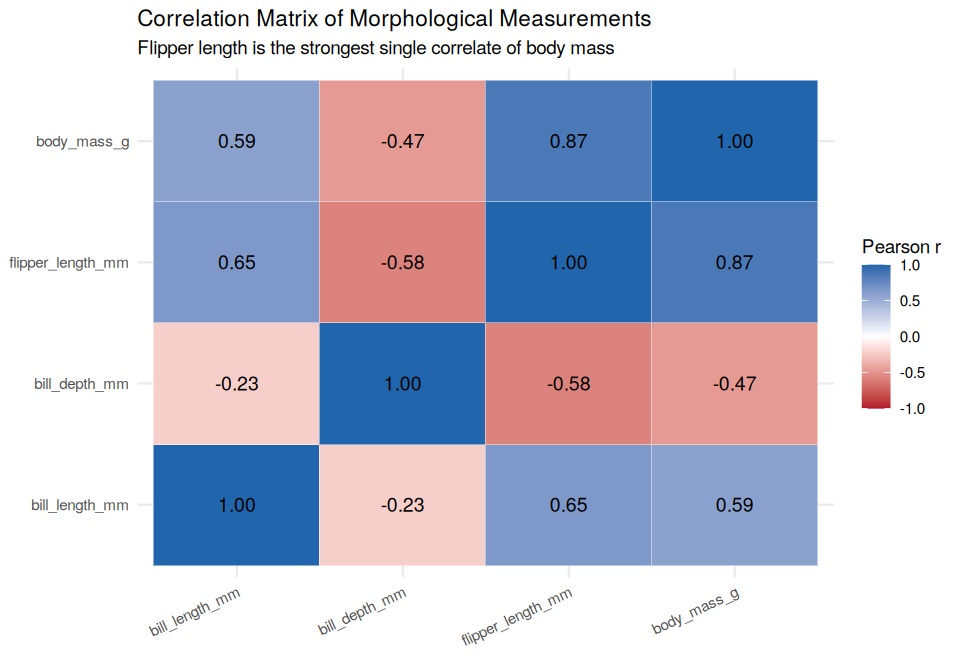

In [11]:
cor_mat <- cor(data_clean[, num_vars])
cor_df  <- as.data.frame(as.table(cor_mat))
names(cor_df) <- c("Var1", "Var2", "r")

p5 <- ggplot(cor_df, aes(x = Var1, y = Var2, fill = r)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.2f", r)), size = 4) +
  scale_fill_gradient2(low = "#B2182B", mid = "white", high = "#2166AC",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Correlation Matrix of Morphological Measurements",
       subtitle = "Flipper length is the strongest single correlate of body mass",
       x = NULL, y = NULL, fill = "Pearson r") +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 25, hjust = 1))
print(p5)

**Chart 6 (new): Does the sex gap in body mass hold within every species? (box plot)**

    species female_mean male_mean gap_g
1    Adelie      3368.8    4043.5 674.7
2 Chinstrap      3527.2    3939.0 411.8
3    Gentoo      4679.7    5484.8 805.1


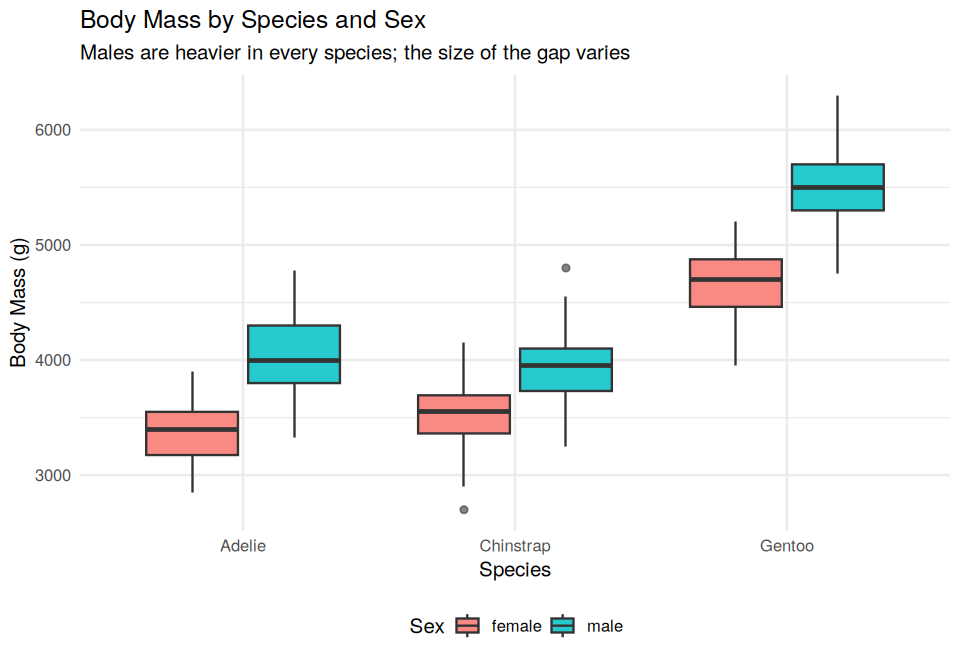

In [12]:
p6 <- ggplot(data_clean, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot(alpha = 0.85, outlier.alpha = 0.6) +
  scale_fill_manual(values = sex_cols) +
  labs(title = "Body Mass by Species and Sex",
       subtitle = "Males are heavier in every species; the size of the gap varies",
       x = "Species", y = "Body Mass (g)", fill = "Sex") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")
print(p6)

gap_m <- with(data_clean, tapply(body_mass_g, list(species, sex), mean))
sex_gap <- data.frame(species = rownames(gap_m),
                      female_mean = round(gap_m[, "female"], 1),
                      male_mean   = round(gap_m[, "male"], 1),
                      gap_g       = round(gap_m[, "male"] - gap_m[, "female"], 1),
                      row.names = NULL)
print(sex_gap)

---
## **4. Statistical Inference** *(Week 3)*

The charts suggest three things: males are heavier, Gentoo is much heavier than the other species, and flipper length tracks body mass closely. This section tests each claim formally and checks whether the tests' assumptions hold.

**Hypothesis 1: Welch's two-sample t-test (body mass by sex)**

H0: mean body mass is equal for males and females. H1: it differs.

In [13]:
ttest_res <- t.test(body_mass_g ~ sex, data = data_clean)
cat("=== TWO-SAMPLE T-TEST: BODY MASS BY SEX ===\n")
print(ttest_res)

# Effect size: Cohen's d (how big is the difference, not just is it significant?)
g <- split(data_clean$body_mass_g, data_clean$sex)
pooled_sd <- sqrt(((length(g$female) - 1) * var(g$female) + (length(g$male) - 1) * var(g$male)) /
                    (length(g$female) + length(g$male) - 2))
cohens_d <- (mean(g$male) - mean(g$female)) / pooled_sd
cat(sprintf("\nMale - female difference: %.1f g | Cohen's d = %.2f\n",
            mean(g$male) - mean(g$female), cohens_d))

=== TWO-SAMPLE T-TEST: BODY MASS BY SEX ===



	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 




Male - female difference: 683.4 g | Cohen's d = 0.94


**Hypothesis 2: One-way ANOVA with Tukey HSD (body mass across species)**

H0: all three species have the same mean body mass. H1: at least one differs.

In [14]:
anova_mod <- aov(body_mass_g ~ species, data = data_clean)
cat("=== ONE-WAY ANOVA: BODY MASS BY SPECIES ===\n")
print(summary(anova_mod))

ss   <- summary(anova_mod)[[1]]
eta2 <- ss[["Sum Sq"]][1] / sum(ss[["Sum Sq"]])
cat(sprintf("\nEta-squared (share of mass variance explained by species): %.3f\n", eta2))

cat("\n=== TUKEY HSD POST-HOC TEST ===\n")
print(TukeyHSD(anova_mod))

=== ONE-WAY ANOVA: BODY MASS BY SPECIES ===


             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



Eta-squared (share of mass variance explained by species): 0.674



=== TUKEY HSD POST-HOC TEST ===


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = data_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



**Hypothesis 3: Pearson correlation (flipper length and body mass)**

H0: the true correlation is zero. H1: it is not.

In [15]:
cor_res <- cor.test(data_clean$flipper_length_mm, data_clean$body_mass_g)
cat("=== PEARSON CORRELATION: FLIPPER LENGTH vs BODY MASS ===\n")
print(cor_res)

=== PEARSON CORRELATION: FLIPPER LENGTH vs BODY MASS ===



	Pearson's product-moment correlation

data:  data_clean$flipper_length_mm and data_clean$body_mass_g
t = 32.562, df = 331, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8447622 0.8963550
sample estimates:
      cor 
0.8729789 



**Assumption checks and a robustness test**

ANOVA assumes roughly normal residuals and similar variances across groups. If these assumptions looked doubtful, the non-parametric Kruskal-Wallis test, which does not depend on them, should reach the same conclusion.

In [16]:
cat("=== SHAPIRO-WILK NORMALITY TEST (ANOVA residuals) ===\n")
print(shapiro.test(residuals(anova_mod)))

cat("=== BARTLETT TEST FOR HOMOSCEDASTICITY ===\n")
print(bartlett.test(body_mass_g ~ species, data = data_clean))

cat("=== KRUSKAL-WALLIS ROBUSTNESS CHECK ===\n")
print(kruskal.test(body_mass_g ~ species, data = data_clean))

=== SHAPIRO-WILK NORMALITY TEST (ANOVA residuals) ===



	Shapiro-Wilk normality test

data:  residuals(anova_mod)
W = 0.9922, p-value = 0.07835



=== BARTLETT TEST FOR HOMOSCEDASTICITY ===



	Bartlett test of homogeneity of variances

data:  body_mass_g by species
Bartlett's K-squared = 5.692, df = 2, p-value = 0.05808



=== KRUSKAL-WALLIS ROBUSTNESS CHECK ===



	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16



---
## **5. Predictive Modeling** *(Week 3, extended)*

**Goal:** predict body mass from morphology, species, sex and island.

**Design:** a 70/30 train-test split; all model choices are made with 5-fold cross-validation on the 70% training set only. The 30% holdout is used once, at the end, to report honest out-of-sample performance.

**5.1 Data split and cross-validation folds**

In [17]:
set.seed(42)
n <- nrow(data_clean)
train_idx <- sample(seq_len(n), size = round(0.70 * n))
train_df  <- data_clean[train_idx, ]
test_df   <- data_clean[-train_idx, ]

folds <- cut(seq_len(nrow(train_df)), breaks = 5, labels = FALSE)
folds <- sample(folds)   # the same folds are reused for every candidate model

cat(sprintf("Training samples: %d (70%%) | Test samples: %d (30%%)\n", nrow(train_df), nrow(test_df)))
print(table(Fold = folds))

Training samples: 233 (70%) | Test samples: 100 (30%)


Fold
 1  2  3  4  5 
47 46 47 46 47 


**5.2 Metric helpers and the Week 3 model**

Every candidate is scored with the same three metrics, so the comparison is fair.

In [18]:
rmse <- function(actual, pred) sqrt(mean((actual - pred)^2))
mae  <- function(actual, pred) mean(abs(actual - pred))
r2   <- function(actual, pred) 1 - sum((actual - pred)^2) / sum((actual - mean(actual))^2)

# Native Variance Inflation Factor
calc_vif <- function(mod) {
  X <- model.matrix(mod)[, -1]
  vifs <- numeric(ncol(X)); names(vifs) <- colnames(X)
  for (i in seq_along(vifs)) {
    r2_i <- summary(lm(X[, i] ~ X[, -i]))$r.squared
    vifs[i] <- 1 / (1 - r2_i)
  }
  vifs
}

f_full <- body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + species + sex + island
model_lm <- do.call("lm", list(formula = f_full, data = quote(train_df)))

cat("=== WEEK 3 MODEL SUMMARY (M1: full additive) ===\n")
print(summary(model_lm))
cat("=== VARIANCE INFLATION FACTORS (M1) ===\n")
print(round(calc_vif(model_lm), 2))

=== WEEK 3 MODEL SUMMARY (M1: full additive) ===



Call:
lm(formula = body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species + sex + island, data = train_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-742.37 -169.52   -6.88  169.91  944.84 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -1425.216    678.504  -2.101 0.036801 *  
bill_length_mm       17.872      8.393   2.129 0.034320 *  
bill_depth_mm        77.617     22.789   3.406 0.000782 ***
flipper_length_mm    15.106      3.410   4.429 1.48e-05 ***
speciesChinstrap   -287.123    105.872  -2.712 0.007207 ** 
speciesGentoo      1020.081    161.943   6.299 1.57e-09 ***
sexmale             362.856     55.503   6.538 4.17e-10 ***
islandDream         -35.272     69.571  -0.507 0.612654    
islandTorgersen    -109.755     73.263  -1.498 0.135517    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 284.6 on 224 degrees of freedom
Multiple R-squared:  0.8814,	Adju

=== VARIANCE INFLATION FACTORS (M1) ===


   bill_length_mm     bill_depth_mm flipper_length_mm  speciesChinstrap     speciesGentoo           sexmale 
             6.25              5.73              6.82              5.11             17.48              2.21 
      islandDream   islandTorgersen 
             3.24              1.83 


**5.3 Model comparison: can the Week 3 model be improved?**

Week 3 suggested two ideas: drop predictors that add nothing, and add interaction terms. Three questions are tested here:

1. Does `island` add anything once species is known? (nested F-test)
2. Does the sex effect differ by species? (`species * sex`, nested F-test)
3. Which candidate predicts best on data it was not fitted on? (cross-validation)

A mean-only baseline is included, because a model is only useful if it beats guessing the average.

In [19]:
candidates <- list(
  "M0 Baseline (mean only)"   = body_mass_g ~ 1,
  "M1 Full additive (Wk 3)"   = f_full,
  "M2 Drop island"            = body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + species + sex,
  "M3 Drop island + species x sex" =
    body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + species * sex
)

cv_scores <- function(formula) {
  rm <- numeric(5); rs <- numeric(5)
  for (k in 1:5) {
    val <- which(folds == k)
    fit <- lm(formula, data = train_df[-val, ])
    pr  <- predict(fit, newdata = train_df[val, ])
    rm[k] <- rmse(train_df$body_mass_g[val], pr)
    rs[k] <- r2(train_df$body_mass_g[val], pr)
  }
  c(CV_RMSE = mean(rm), CV_R2 = mean(rs))
}

fits <- lapply(candidates, function(f) do.call("lm", list(formula = f, data = quote(train_df))))

comparison <- do.call(rbind, lapply(names(candidates), function(nm) {
  fit <- fits[[nm]]
  cv  <- cv_scores(candidates[[nm]])
  pr  <- predict(fit, newdata = test_df)
  data.frame(Model = nm,
             Adj_R2    = round(summary(fit)$adj.r.squared, 4),
             AIC       = round(AIC(fit), 1),
             CV_RMSE   = round(cv["CV_RMSE"], 2),
             CV_R2     = round(cv["CV_R2"], 4),
             Test_RMSE = round(rmse(test_df$body_mass_g, pr), 2),
             Test_MAE  = round(mae(test_df$body_mass_g, pr), 2),
             Test_R2   = round(r2(test_df$body_mass_g, pr), 4),
             row.names = NULL)
}))
print(comparison, row.names = FALSE)

cat("\n=== NESTED F-TEST: does island add anything? (M2 vs M1) ===\n")
print(anova(fits[["M2 Drop island"]], fits[["M1 Full additive (Wk 3)"]]))
cat("=== NESTED F-TEST: does the sex effect depend on species? (M2 vs M3) ===\n")
print(anova(fits[["M2 Drop island"]], fits[["M3 Drop island + species x sex"]]))

# Selection rule: lowest cross-validated RMSE (training data only, never the holdout)
best_name   <- comparison$Model[which.min(comparison$CV_RMSE)]
final_model <- fits[[best_name]]
cat("\nSelected model (lowest CV RMSE):", best_name, "\n")

                          Model Adj_R2    AIC CV_RMSE   CV_R2 Test_RMSE Test_MAE Test_R2
        M0 Baseline (mean only) 0.0000 3786.2  809.06 -0.0180    789.17   652.51  0.0000
        M1 Full additive (Wk 3) 0.8771 3305.5  287.77  0.8661    300.12   241.56  0.8554
                 M2 Drop island 0.8769 3304.0  287.78  0.8661    296.44   239.62  0.8589
 M3 Drop island + species x sex 0.8847 3290.7  279.49  0.8725    285.04   229.75  0.8695



=== NESTED F-TEST: does island add anything? (M2 vs M1) ===


Analysis of Variance Table

Model 1: body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species + sex
Model 2: body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species + sex + island
  Res.Df      RSS Df Sum of Sq      F Pr(>F)
1    226 18340374                           
2    224 18147017  2    193357 1.1934 0.3051


=== NESTED F-TEST: does the sex effect depend on species? (M2 vs M3) ===


Analysis of Variance Table

Model 1: body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species + sex
Model 2: body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species * sex
  Res.Df      RSS Df Sum of Sq      F    Pr(>F)    
1    226 18340374                                  
2    224 17031350  2   1309024 8.6083 0.0002501 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



Selected model (lowest CV RMSE): M3 Drop island + species x sex 


**5.4 The selected model**

In [20]:
print(summary(final_model))
cat("=== VIF AFTER DROPPING ISLAND (M2, additive) ===\n")
print(round(calc_vif(fits[["M2 Drop island"]]), 2))


Call:
lm(formula = body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species * sex, data = train_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-724.56 -148.84   -5.95  157.29  908.00 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)              -1670.077    668.894  -2.497 0.013253 *  
bill_length_mm              19.443      8.114   2.396 0.017388 *  
bill_depth_mm               84.059     22.067   3.809 0.000180 ***
flipper_length_mm           15.077      3.294   4.577 7.83e-06 ***
speciesChinstrap          -107.415    104.505  -1.028 0.305134    
speciesGentoo             1061.096    149.807   7.083 1.80e-11 ***
sexmale                    409.348     64.654   6.331 1.31e-09 ***
speciesChinstrap:sexmale  -366.929     99.298  -3.695 0.000276 ***
speciesGentoo:sexmale       25.313     81.901   0.309 0.757556    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 275.

=== VIF AFTER DROPPING ISLAND (M2, additive) ===


   bill_length_mm     bill_depth_mm flipper_length_mm  speciesChinstrap     speciesGentoo           sexmale 
             6.21              5.69              6.65              4.37             15.31              2.20 


**5.5 Holdout evaluation and residual diagnostics**

The holdout set was untouched while models were chosen. The four-panel plot checks the assumptions behind a linear model: no curved pattern in the residuals, roughly normal errors, constant spread, and no single point that dominates the fit.

In [21]:
test_preds <- predict(final_model, newdata = test_df)
cat(sprintf("=== HOLDOUT PERFORMANCE OF SELECTED MODEL (N = %d) ===\nRMSE: %.2f g\nMAE:  %.2f g\nR2:   %.4f\n",
            nrow(test_df), rmse(test_df$body_mass_g, test_preds),
            mae(test_df$body_mass_g, test_preds), r2(test_df$body_mass_g, test_preds)))

=== HOLDOUT PERFORMANCE OF SELECTED MODEL (N = 100) ===
RMSE: 285.04 g
MAE:  229.75 g
R2:   0.8695


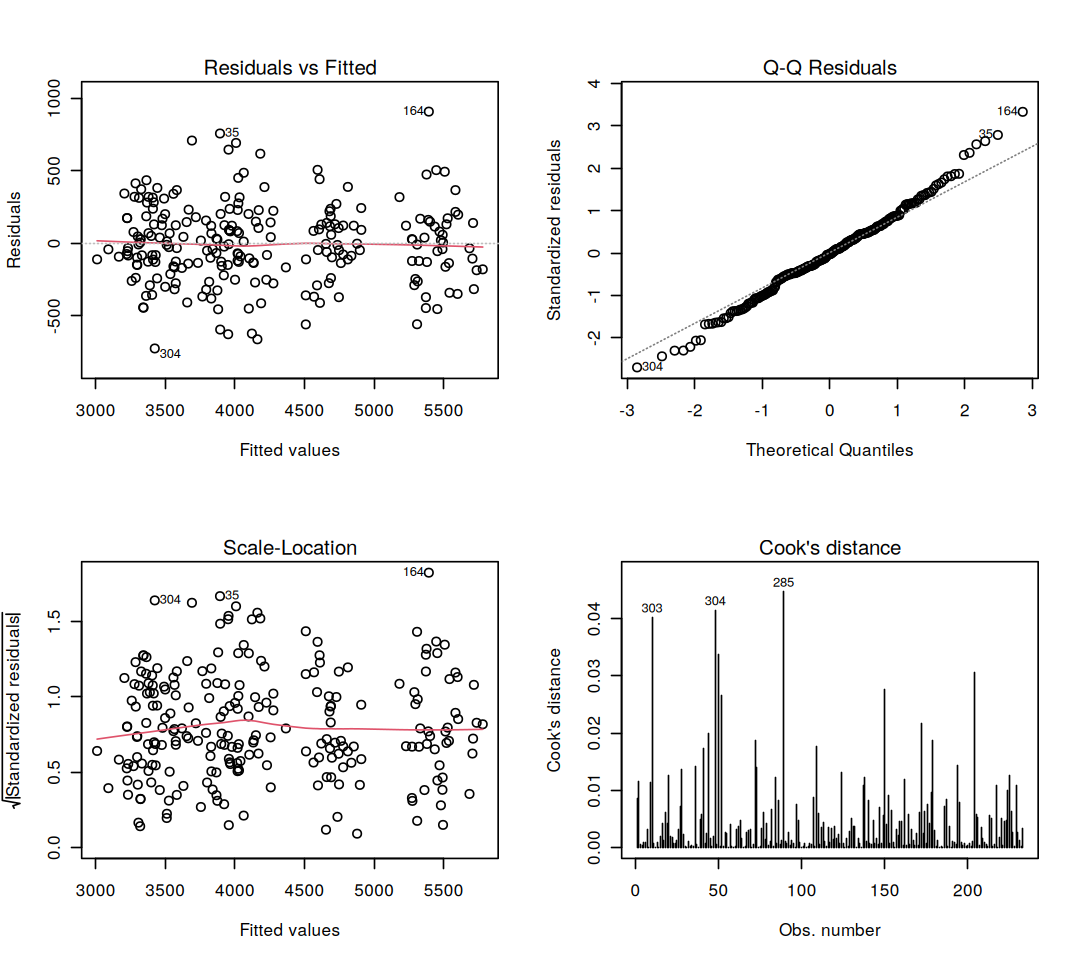

In [22]:
options(repr.plot.width = 9, repr.plot.height = 8)
par(mfrow = c(2, 2))
plot(final_model, which = 1:4)
par(mfrow = c(1, 1))
options(repr.plot.width = 8, repr.plot.height = 5.5)

In [23]:
res_final <- residuals(final_model)
cat("=== RESIDUAL CHECKS (selected model, training data) ===\n")
print(shapiro.test(res_final))
cat(sprintf("Largest Cook's distance: %.3f (rule of thumb: investigate above 0.5)\n", max(cooks.distance(final_model))))
cat(sprintf("Observations with |standardized residual| > 3: %d\n", sum(abs(rstandard(final_model)) > 3)))

=== RESIDUAL CHECKS (selected model, training data) ===



	Shapiro-Wilk normality test

data:  res_final
W = 0.9931, p-value = 0.3531



Largest Cook's distance: 0.045 (rule of thumb: investigate above 0.5)


Observations with |standardized residual| > 3: 1


**5.6 Predicted versus actual body mass (holdout set)**

    species  n  RMSE   MAE
1    Adelie 44 297.8 241.0
2 Chinstrap 22 271.2 217.3
3    Gentoo 34 276.8 223.2


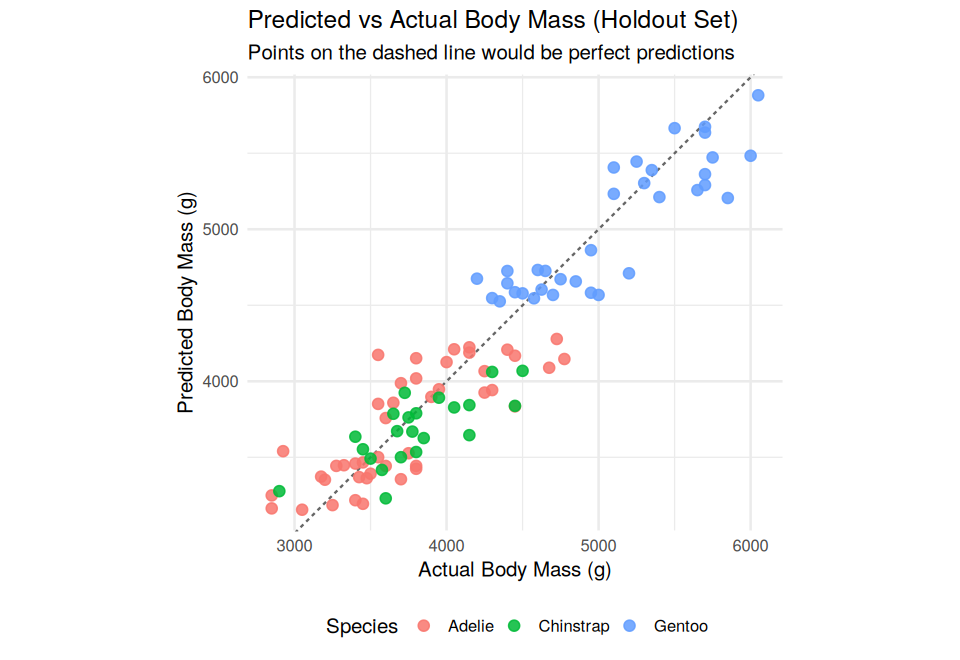

In [24]:
pred_df <- data.frame(actual = test_df$body_mass_g, predicted = test_preds, species = test_df$species)

p7 <- ggplot(pred_df, aes(x = actual, y = predicted, color = species)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
  geom_point(size = 2.5, alpha = 0.85) +
  scale_color_manual(values = species_cols) +
  labs(title = "Predicted vs Actual Body Mass (Holdout Set)",
       subtitle = "Points on the dashed line would be perfect predictions",
       x = "Actual Body Mass (g)", y = "Predicted Body Mass (g)", color = "Species") +
  coord_equal() + theme_minimal(base_size = 12) + theme(legend.position = "bottom")
print(p7)

err_by_species <- pred_df %>% group_by(species) %>%
  summarise(n = n(), RMSE = round(rmse(actual, predicted), 1), MAE = round(mae(actual, predicted), 1), .groups = "drop")
print(as.data.frame(err_by_species))

---
## **6. Results Consolidation**

All headline numbers from the four weeks, computed directly from the objects above so that nothing is typed in by hand.

In [25]:
sel <- comparison[comparison$Model == best_name, ]
m1  <- comparison[comparison$Model == "M1 Full additive (Wk 3)", ]
m0  <- comparison[comparison$Model == "M0 Baseline (mean only)", ]
tuk <- TukeyHSD(anova_mod)$species

key_findings <- data.frame(
  Area = c("Data", "Data", "Visualization", "Visualization", "Inference", "Inference", "Inference",
           "Modeling", "Modeling", "Modeling"),
  Finding = c(
    sprintf("%d of %d records used after removing %d with missing values", nrow(data_clean), nrow(penguins), nrow(penguins) - nrow(data_clean)),
    sprintf("Sex ratio is balanced: %d females and %d males", sum(data_clean$sex == "female"), sum(data_clean$sex == "male")),
    sprintf("Simpson's paradox: pooled bill r = %.2f, but every species is positive (%.2f to %.2f)", overall_r, min(within_r), max(within_r)),
    "Chinstrap and Gentoo each live on a single island, so island and species overlap",
    sprintf("Males are %.0f g heavier than females (Welch p %s, Cohen's d = %.2f)", mean(g$male) - mean(g$female),
            format.pval(ttest_res$p.value, digits = 2), cohens_d),
    sprintf("Species explains %.0f%% of body mass variance; Gentoo is %.0f g heavier than Adelie, Chinstrap vs Adelie p = %.2f",
            100 * eta2, tuk["Gentoo-Adelie", "diff"], tuk["Chinstrap-Adelie", "p adj"]),
    sprintf("Flipper length and body mass correlate at r = %.2f", cor_res$estimate),
    sprintf("Guessing the mean gives a holdout RMSE of %.0f g", m0$Test_RMSE),
    sprintf("Week 3 model: CV RMSE %.0f g, holdout RMSE %.0f g (R2 = %.3f)", m1$CV_RMSE, m1$Test_RMSE, m1$Test_R2),
    sprintf("Selected model (%s): CV RMSE %.0f g, holdout RMSE %.0f g (R2 = %.3f)", best_name, sel$CV_RMSE, sel$Test_RMSE, sel$Test_R2)
  )
)
print(key_findings, right = FALSE, row.names = FALSE)

 Area         
 Data         
 Data         
 Visualization
 Visualization
 Inference    
 Inference    
 Inference    
 Modeling     
 Modeling     
 Modeling     
 Finding                                                                                                       
 333 of 344 records used after removing 11 with missing values                                                 
 Sex ratio is balanced: 165 females and 168 males                                                              
 Simpson's paradox: pooled bill r = -0.23, but every species is positive (0.39 to 0.65)                        
 Chinstrap and Gentoo each live on a single island, so island and species overlap                              
 Males are 683 g heavier than females (Welch p 4.8e-16, Cohen's d = 0.94)                                      
 Species explains 67% of body mass variance; Gentoo is 1386 g heavier than Adelie, Chinstrap vs Adelie p = 0.92
 Flipper length and body mass correlate at r = 0.87

---
## **7. Discussion**

**7.1 What the evidence shows**

- **Species and sex drive body size.** Gentoo penguins average about 5,092 g against roughly 3,700 g for Adelie and Chinstrap. Species alone explains 67% of the variation in body mass (eta-squared = 0.674), and Adelie and Chinstrap cannot be told apart by mass (Tukey p = 0.92). Males are about 683 g heavier than females (Cohen's d = 0.94, a large effect).
- **The sex gap is not the same in every species.** Males outweigh females by roughly 675 g in Adelie, 805 g in Gentoo and only 412 g in Chinstrap. The significant `species x sex` interaction (F-test p = 0.0003) confirms that this is a real pattern and not noise. It is also why the interaction model beat the additive Week 3 model.
- **Pooled data can mislead.** Bill length and bill depth are negatively correlated overall (r = -0.23) but positively correlated inside every species (r = 0.39 to 0.65). This is Simpson's paradox: any analysis that ignored species would have drawn the wrong conclusion about bill shape.
- **Flipper length is the best single measurement.** It correlates with body mass at r = 0.87, and each extra millimetre adds about 15 g after species, sex and bill size are held constant.
- **Island adds nothing once species is known.** The F-test for dropping `island` gives p = 0.31, and removing it left predictive accuracy unchanged. Island and species overlap heavily (all Chinstraps live on Dream, all Gentoos on Biscoe), so an island effect cannot be separated from a species effect in this dataset.

**7.2 Statistical versus practical significance**

Almost every test here is highly significant, so significance alone says little. The effect sizes carry the message: a 683 g sex gap and a 1,386 g Gentoo gap are large relative to a typical spread (standard deviation) of about 450 g within a group. The model's holdout error of 285 g is about 7% of the average body mass (roughly 4,200 g) and 64% lower than the 789 g error from simply guessing the mean. That is a useful but not perfect predictor.

**7.3 Implications for practice**

- **Non-invasive monitoring.** Field teams can estimate a penguin's body mass from a flipper measurement, species and sex, without weighing the bird. At about +/- 285 g per animal, this suits tracking colony-level averages over time better than judging an individual bird's condition.
- **Simpler data collection.** Because island adds no predictive value, it can be dropped from the mass-prediction protocol. It should still be recorded for sampling design.
- **Analyse by group.** Because the sex gap and the bill relationships differ by species, results should be reported per species, never only as a pooled average.
- **Sampling design.** The sex ratio is nearly even (165 females, 168 males), which supports unbiased comparisons. Because two species occupy a single island, any future question about the effect of place needs Adelie, the only species seen on all three islands.

**7.4 Limitations**

- **Observational data from one archipelago over three years (2007-2009).** The results describe these penguins and do not show causes. Mean flipper length also rose by roughly 2-3% from 2007 to 2008 in Adelie and Chinstrap before levelling off, so conditions may not be constant across years.
- **Multicollinearity.** Variance inflation factors stay above 5 for the bill and flipper measurements and reach 15 for the Gentoo indicator, because species is closely tied to body size. This makes individual coefficients less stable to interpret, but it does not harm the predictions, which cross-validation and the holdout both confirm.
- **Small holdout set.** With 100 test penguins, the holdout RMSE is itself an uncertain estimate, which is why model choice relied on cross-validation and the holdout was used only once.
- **Complete-case deletion.** Removing 11 records (3.2%) assumes that missingness is unrelated to body size. This is plausible but untested.
- **Borderline assumptions.** The Shapiro-Wilk (p = 0.078) and Bartlett (p = 0.058) tests were close to the 0.05 line. The Kruskal-Wallis test, which does not depend on these assumptions, reached the same conclusion (p < 2.2e-16), so the species result is robust.

---
## **8. Conclusion**

**8.1 Summary**

Starting from 344 raw records, the pipeline cleaned the data (333 retained), visualised the main patterns, tested three hypotheses formally and built a regression model that predicts body mass with a holdout R-squared of 0.87 and an average error of about 285 g. Each stage informed the next: the charts motivated the hypotheses, the hypotheses chose the predictors, and the model comparison showed that the sex effect depends on species.

**8.2 Lessons learned**

- **Look before you model.** The charts exposed Simpson's paradox and the species-island overlap before any model was fitted, which prevented misleading conclusions.
- **Report effect sizes, not only p-values.** With 333 observations nearly everything is significant; Cohen's d and eta-squared show what actually matters.
- **Always compare with a baseline.** The mean-only model (RMSE 789 g) gives the 285 g error its meaning.
- **Protect the test set.** Selecting models by cross-validation on the training data kept the holdout result honest, and the close agreement between CV (279 g) and holdout (285 g) shows no overfitting.
- **Check assumptions and test robustness.** When two assumption tests landed near the 0.05 threshold, a non-parametric test confirmed the conclusion.

**8.3 Challenges overcome**

- **Missing values:** 11 records lacked sex or measurements; they were removed and logged in a cleaning table.
- **Misleading aggregate correlations:** solved by stratifying every relationship by species.
- **Multicollinearity:** the variance inflation factors were examined, explained by the link between species and body size, and shown not to damage predictive accuracy.
- **Choosing between models fairly:** all candidates used identical folds and the same metrics, with nested F-tests supporting the decisions.
- **Reproducibility:** a fixed seed, fixed folds and a single top-to-bottom notebook make every number repeatable.

**8.4 Future directions**

- Fit **regularised regression** (ridge, lasso, elastic net), which handles correlated predictors directly.
- Try **tree ensembles** (random forest, gradient boosting) to capture non-linear relationships automatically, and compare them against the linear model on the same folds.
- Use **repeated cross-validation** or a bootstrap to put confidence intervals around the performance metrics.
- Add **prediction intervals** so field teams can see the uncertainty for each individual estimate.
- Extend the data with **more years, more colonies and diet or climate variables**, and test whether the species-specific patterns persist.
- Move from regression to **classification**, for example predicting species from morphology, to complete the analytical toolkit.

In [26]:
cat("R:", R.version.string, "\n")
for (p in pkgs) cat(sprintf("%-15s %s\n", p, as.character(packageVersion(p))))

R: R version 4.3.3 (2024-02-29) 


palmerpenguins  0.1.1
ggplot2         3.4.4
dplyr           1.1.4
